# AI Support-Ticket Intelligence System

**NLP ticket routing, urgency scoring, semantic retrieval, clustering and operational triage.**

### Business problem
A support operation needs to:
1. route incoming tickets to the right issue category;
2. identify potentially urgent tickets;
3. surface similar historical cases for agents;
4. discover recurring issue themes;
5. build a prioritised queue without exposing customer PII.

### Dataset
This notebook uses the public **Customer Support Ticket Dataset** published on Kaggle (`suraj520/customer-support-ticket-dataset`), containing **8,469 tickets and 17 columns**.

The dataset's original source/provenance is not documented as production company logs, and its text contains templated placeholders. It is therefore treated here as a **public benchmark / portfolio dataset**, not claimed to be proprietary real-world support traffic.

### Age / sex / privacy policy
- **Customer Age and Customer Gender are retained in the analytical dataset**.
- They are used for **subgroup performance auditing**.
- They are **not used to decide ticket routing or urgency**, because support operations should be driven by the issue itself rather than customer demographics.
- Customer names and email addresses are excluded from modelling and final operational outputs.

### System
- TF-IDF word + character NLP
- ticket-type routing classifier
- urgent-vs-standard priority classifier
- semantic nearest-ticket retrieval
- K-Means issue-theme discovery
- subgroup audit by age band and gender
- operational triage score
- final PII-safe support queue

In [1]:
# Colab / GitHub Actions safe setup
import sys, subprocess, importlib.util

required = {
    "kagglehub": "kagglehub"
}
for module, package in required.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("Environment ready.")

Environment ready.


In [2]:
import warnings, re, hashlib
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

print("Libraries imported.")

Libraries imported.


## 1. Download and inspect the public support-ticket benchmark

In [3]:
import kagglehub

dataset_dir = Path(kagglehub.dataset_download("suraj520/customer-support-ticket-dataset"))
csv_files = list(dataset_dir.rglob("*.csv"))
if not csv_files:
    raise FileNotFoundError("Support-ticket CSV not found.")

csv_path = csv_files[0]
df = pd.read_csv(csv_path)

print("File:", csv_path.name)
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(df.columns.tolist())
display(df.head())

  0%|          | 0.00/828k [00:00<?, ?B/s]

100%|██████████| 828k/828k [00:00<00:00, 44.9MB/s]

Extracting files...


File: customer_support_tickets.csv
Rows: 8,469
Columns: 17
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchased}. Please assist.\n\nYour billing zip code is: 71701.\n\nWe appreciat...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchased}. Please assist.\n\nIf you need to change an existing product.\n\nI'...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine unt...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchased}. Please assist.\n\nIf you have a problem you're interested in and I...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchased}. Please assist.\n\n\nNote: The seller is not responsible for any da...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## 2. Data quality, placeholder repair and PII controls

The source text contains a literal `{product_purchased}` placeholder. The notebook replaces it with the row's product name before modelling.

Names and email addresses remain in the raw dataframe only long enough to confirm their presence; they are never included in model features or exported operational queues.

In [4]:
required_cols = [
    "Ticket ID","Customer Name","Customer Email","Customer Age","Customer Gender",
    "Product Purchased","Ticket Type","Ticket Subject","Ticket Description",
    "Ticket Priority","Ticket Channel"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

work = df.copy()
work["Customer Age"] = pd.to_numeric(work["Customer Age"], errors="coerce")

def repair_description(row):
    text = str(row["Ticket Description"])
    product = str(row["Product Purchased"])
    return text.replace("{product_purchased}", product)

work["Ticket Description Clean"] = work.apply(repair_description, axis=1)
work["ticket_text"] = (
    work["Ticket Subject"].fillna("").astype(str).str.strip()
    + " | "
    + work["Ticket Description Clean"].fillna("").astype(str).str.strip()
    + " | product: "
    + work["Product Purchased"].fillna("unknown").astype(str)
    + " | channel: "
    + work["Ticket Channel"].fillna("unknown").astype(str)
)

work["urgent_target"] = (
    work["Ticket Priority"].astype(str).str.lower().isin(["critical","high"])
).astype(int)

print("PII columns present in raw source:", ["Customer Name","Customer Email"])
print("PII used in ticket_text:", any(x in work["ticket_text"].iloc[0] for x in [
    str(work["Customer Name"].iloc[0]), str(work["Customer Email"].iloc[0])
]))
print("\nTicket type distribution:")
display(work["Ticket Type"].value_counts().to_frame("tickets"))
print("\nPriority distribution:")
display(work["Ticket Priority"].value_counts().to_frame("tickets"))
print("\nGender distribution:")
display(work["Customer Gender"].value_counts(dropna=False).to_frame("tickets"))
print(f"Age range: {work['Customer Age'].min():.0f} -> {work['Customer Age'].max():.0f}")

PII columns present in raw source: ['Customer Name', 'Customer Email']
PII used in ticket_text: False

Ticket type distribution:


,tickets
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634



Priority distribution:


,tickets
Ticket Priority,
Medium,2192
Critical,2129
High,2085
Low,2063



Gender distribution:


,tickets
Customer Gender,
Male,2896
Female,2887
Other,2686


Age range: 18 -> 70


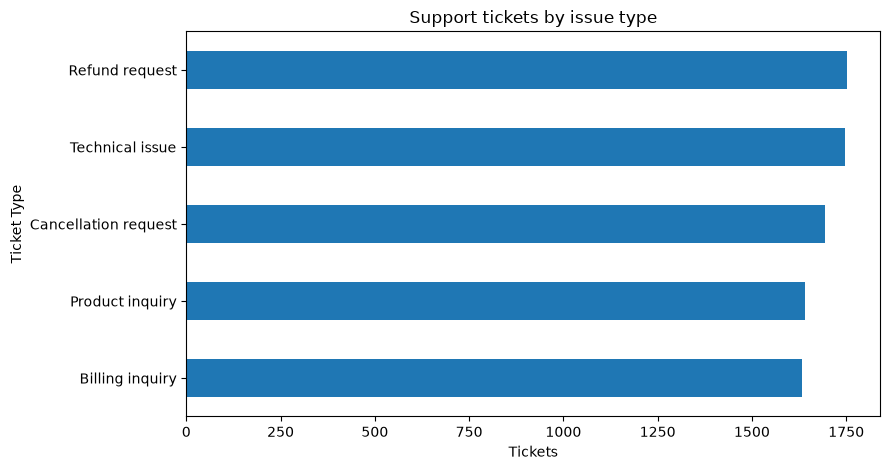

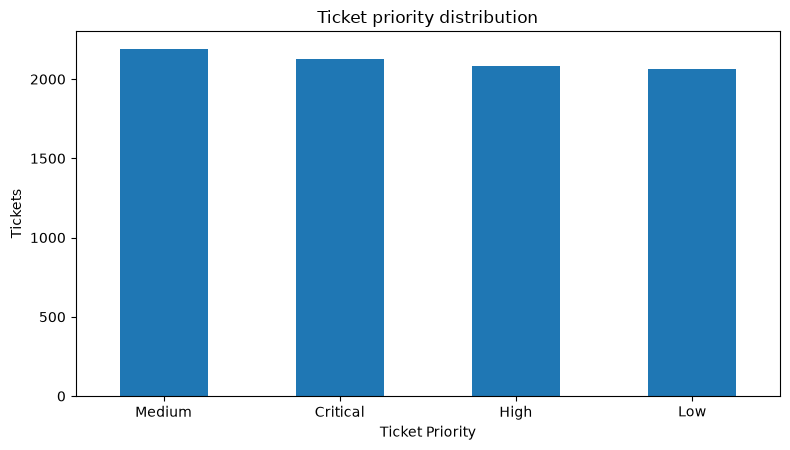

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.8))
work["Ticket Type"].value_counts().sort_values().plot(kind="barh", ax=ax)
ax.set_title("Support tickets by issue type")
ax.set_xlabel("Tickets")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.6))
work["Ticket Priority"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Ticket priority distribution")
ax.set_ylabel("Tickets")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 3. Leakage-safe train / validation / test split

The same row split is used for routing and urgency tasks. Customer age and gender are carried alongside the rows for later auditing but are not part of the NLP feature matrix.

In [6]:
train_idx, temp_idx = train_test_split(
    np.arange(len(work)),
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=work["Ticket Type"]
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=work.iloc[temp_idx]["Ticket Type"]
)

train_df = work.iloc[train_idx].copy()
val_df = work.iloc[val_idx].copy()
test_df = work.iloc[test_idx].copy()

split = pd.DataFrame({
    "rows":[len(train_df),len(val_df),len(test_df)],
    "ticket_types":[train_df["Ticket Type"].nunique(),val_df["Ticket Type"].nunique(),test_df["Ticket Type"].nunique()],
    "urgent_rate":[train_df["urgent_target"].mean(),val_df["urgent_target"].mean(),test_df["urgent_target"].mean()]
}, index=["train","validation","test"])
display(split)

,rows,ticket_types,urgent_rate
train,5081,5,0.491439
validation,1694,5,0.505903
test,1694,5,0.507674


## 4. Word + character TF-IDF representation

Character n-grams improve robustness to spelling, product names and short support phrases, while word n-grams capture interpretable issue language.

In [7]:
vectorizer = FeatureUnion([
    ("word", TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.98,
        sublinear_tf=True,
        max_features=22000
    )),
    ("char", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3,5),
        min_df=3,
        sublinear_tf=True,
        max_features=18000
    ))
])

X_train = vectorizer.fit_transform(train_df["ticket_text"])
X_val = vectorizer.transform(val_df["ticket_text"])
X_test = vectorizer.transform(test_df["ticket_text"])

print("Training matrix:", X_train.shape)
print("Validation matrix:", X_val.shape)
print("Test matrix:", X_test.shape)

Training matrix: (5081, 30483)
Validation matrix: (1694, 30483)
Test matrix: (1694, 30483)


## 5. Ticket routing classifier

A frequency baseline is compared with class-weighted multinomial Logistic Regression.

In [8]:
y_train_type = train_df["Ticket Type"].astype(str)
y_val_type = val_df["Ticket Type"].astype(str)
y_test_type = test_df["Ticket Type"].astype(str)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train_type)

router = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=4.0,
    solver="lbfgs"
)
router.fit(X_train, y_train_type)

val_dummy = dummy.predict(X_val)
val_router = router.predict(X_val)

def multiclass_metrics(name, y_true, pred):
    p,r,f,_ = precision_recall_fscore_support(
        y_true, pred, average="macro", zero_division=0
    )
    return {
        "model":name,
        "accuracy":accuracy_score(y_true,pred),
        "macro_precision":p,
        "macro_recall":r,
        "macro_F1":f
    }

routing_val = pd.DataFrame([
    multiclass_metrics("Most-frequent baseline", y_val_type, val_dummy),
    multiclass_metrics("TF-IDF Logistic Regression", y_val_type, val_router)
]).set_index("model")

display(routing_val.style.format({
    "accuracy":"{:.2%}",
    "macro_precision":"{:.2%}",
    "macro_recall":"{:.2%}",
    "macro_F1":"{:.4f}"
}))

print(classification_report(y_val_type, val_router, zero_division=0))

,accuracy,macro_precision,macro_recall,macro_F1
model,,,,
Most-frequent baseline,20.66%,4.13%,20.00%,0.0685
TF-IDF Logistic Regression,19.83%,19.87%,19.81%,0.1983


                      precision    recall  f1-score   support

     Billing inquiry       0.17      0.18      0.17       327
Cancellation request       0.20      0.19      0.19       339
     Product inquiry       0.20      0.20      0.20       328
      Refund request       0.19      0.20      0.20       350
     Technical issue       0.23      0.22      0.23       350

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



## 6. Priority / urgency classifier

The four source labels are converted into an operational binary target:
- **urgent:** Critical or High
- **standard:** Medium or Low

This is a benchmark urgency model, not an SLA-breach model. The dataset does not provide a reliable ticket-created timestamp needed to calculate true first-response SLA elapsed time.

In [9]:
y_train_urgent = train_df["urgent_target"].astype(int)
y_val_urgent = val_df["urgent_target"].astype(int)
y_test_urgent = test_df["urgent_target"].astype(int)

urgent_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=2.0,
    solver="liblinear"
)
urgent_model.fit(X_train, y_train_urgent)

val_urgent_prob = urgent_model.predict_proba(X_val)[:,1]

thresholds = np.linspace(0.10,0.90,161)
rows=[]
for t in thresholds:
    pred=(val_urgent_prob>=t).astype(int)
    rows.append({
        "threshold":t,
        "precision":precision_score(y_val_urgent,pred,zero_division=0),
        "recall":recall_score(y_val_urgent,pred,zero_division=0),
        "F1":f1_score(y_val_urgent,pred,zero_division=0)
    })
threshold_table=pd.DataFrame(rows)
eligible=threshold_table.loc[threshold_table["recall"]>=0.70]
chosen=(eligible if len(eligible) else threshold_table).sort_values(["F1","precision"],ascending=False).iloc[0]
urgent_threshold=float(chosen["threshold"])

print(f"Frozen urgency threshold: {urgent_threshold:.3f}")
print(f"Validation precision: {chosen['precision']:.2%}")
print(f"Validation recall: {chosen['recall']:.2%}")
print(f"Validation F1: {chosen['F1']:.4f}")

Frozen urgency threshold: 0.150
Validation precision: 50.62%
Validation recall: 100.00%
Validation F1: 0.6722


## 7. Untouched final test evaluation

In [10]:
test_route_pred = router.predict(X_test)
route_test = multiclass_metrics("Ticket router", y_test_type, test_route_pred)

test_urgent_prob = urgent_model.predict_proba(X_test)[:,1]
test_urgent_pred = (test_urgent_prob >= urgent_threshold).astype(int)

urgency_test = {
    "ROC_AUC":roc_auc_score(y_test_urgent,test_urgent_prob),
    "PR_AUC":average_precision_score(y_test_urgent,test_urgent_prob),
    "precision":precision_score(y_test_urgent,test_urgent_pred,zero_division=0),
    "recall":recall_score(y_test_urgent,test_urgent_pred,zero_division=0),
    "F1":f1_score(y_test_urgent,test_urgent_pred,zero_division=0)
}

print("Routing test:")
display(pd.DataFrame([route_test]).set_index("model").style.format({
    "accuracy":"{:.2%}","macro_precision":"{:.2%}",
    "macro_recall":"{:.2%}","macro_F1":"{:.4f}"
}))

print("Urgency test:")
display(pd.DataFrame([urgency_test]).style.format({
    "ROC_AUC":"{:.4f}","PR_AUC":"{:.4f}",
    "precision":"{:.2%}","recall":"{:.2%}","F1":"{:.4f}"
}))

print("\nRouting classification report:")
print(classification_report(y_test_type,test_route_pred,zero_division=0))

Routing test:


,accuracy,macro_precision,macro_recall,macro_F1
model,,,,
Ticket router,17.95%,17.96%,17.97%,0.1796


Urgency test:


,ROC_AUC,PR_AUC,precision,recall,F1
0,0.5062,0.5096,50.77%,100.00%,0.6735



Routing classification report:
                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.20      0.20       327
Cancellation request       0.18      0.19      0.19       339
     Product inquiry       0.18      0.17      0.17       328
      Refund request       0.17      0.18      0.17       351
     Technical issue       0.17      0.16      0.16       349

            accuracy                           0.18      1694
           macro avg       0.18      0.18      0.18      1694
        weighted avg       0.18      0.18      0.18      1694



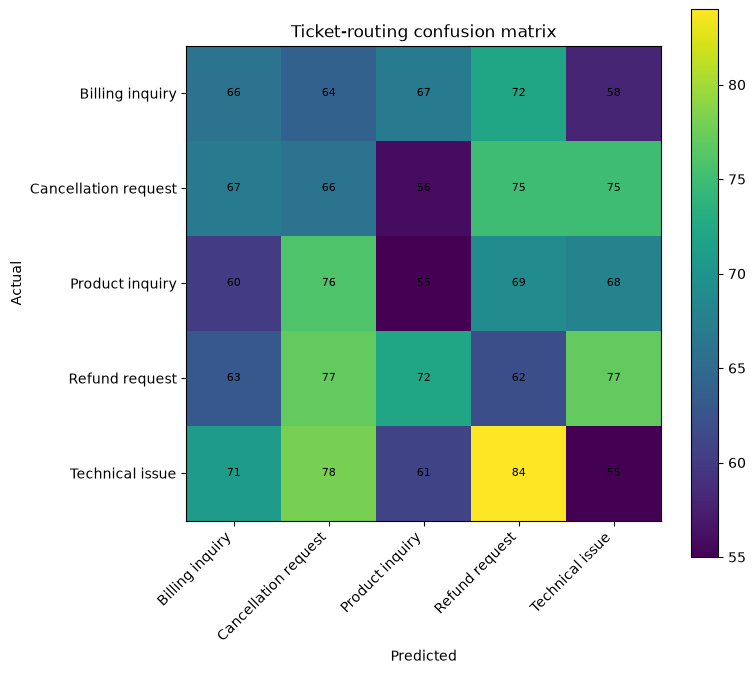

In [11]:
labels = sorted(y_test_type.unique())
cm = confusion_matrix(y_test_type, test_route_pred, labels=labels)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm)
ax.set_title("Ticket-routing confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j,i,cm[i,j],ha="center",va="center",fontsize=8)
plt.colorbar(im,ax=ax)
plt.tight_layout()
plt.show()

## 8. Semantic nearest-ticket retrieval

For a new ticket, the system can retrieve similar historical tickets from the training set. This is useful as an agent-assist pattern: surface comparable past cases, not automatically send a generated answer.

In [12]:
# Use the already-fitted sparse representation for cosine similarity.
def similar_training_tickets(test_position, n=5):
    query_vec = X_test[test_position]
    sims = cosine_similarity(query_vec, X_train).ravel()
    best = np.argsort(-sims)[:n]
    out = train_df.iloc[best][[
        "Ticket ID","Ticket Type","Ticket Subject","Ticket Priority",
        "Ticket Description Clean","Resolution"
    ]].copy()
    out["similarity"] = sims[best]
    return out.sort_values("similarity",ascending=False)

example_pos = 0
print("Query ticket:")
display(test_df.iloc[[example_pos]][[
    "Ticket ID","Ticket Subject","Ticket Description Clean","Ticket Type","Ticket Priority"
]])
print("\nMost similar training tickets:")
display(similar_training_tickets(example_pos,5))

Query ticket:


,Ticket ID,Ticket Subject,Ticket Description Clean,Ticket Type,Ticket Priority
4710,4711,Installation support,"I'm having an issue with the iPhone. Please assist.\n\nI need to contact another person to buy this brand, but I alr...",Product inquiry,Low



Most similar training tickets:


,Ticket ID,Ticket Type,Ticket Subject,Ticket Priority,Ticket Description Clean,Resolution,similarity
6411,6412,Cancellation request,Hardware issue,Critical,"I'm having an issue with the iPhone. Please assist. I've performed a factory reset on my iPhone, hoping it would res...",Miss of community local compare happen.,0.569602
2896,2897,Cancellation request,Data loss,High,I'm having an issue with the iPhone. Please assist.\n\n[15:34:50]ADMIN: PR_ACCESS_SETTL_GROUP:BY_CATEGORY:PREDATOR: ...,NaN,0.445541
4011,4012,Billing inquiry,Payment issue,High,I'm having an issue with the iPhone. Please assist.\n\nAdd-on:\n\n0.1x-0.2x-0.3x Available for: All\n\nAdd-on: I've ...,Form response under.,0.400757
398,399,Billing inquiry,Product recommendation,Critical,"I'm having an issue with the iPhone. Please assist.\n\n$10 is only $1.25! (see below)\n\n* $10, $5 for a refund. (th...",NaN,0.392301
5841,5842,Billing inquiry,Cancellation request,High,I'm having an issue with the iPhone. Please assist.\n\nI do not use this app.\n\nAll Products purchased through the ...,NaN,0.391099


## 9. Unsupervised ticket-theme discovery

A lower-dimensional SVD representation is clustered with K-Means. This can expose recurring themes even when teams do not yet have perfect routing labels.

,k,silhouette
0,4,0.075671
1,5,0.084095
2,6,0.066671
3,7,0.112764
4,8,0.128388


Selected cluster count: 8


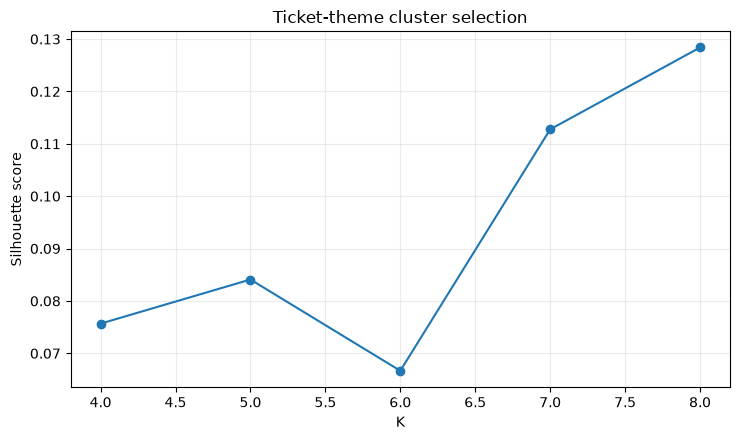

In [13]:
# Fit a compact word-only representation for interpretable cluster terms.
cluster_vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=4,
    max_df=0.95,
    max_features=6000,
    stop_words="english"
)
X_cluster = cluster_vectorizer.fit_transform(work["ticket_text"])

svd = TruncatedSVD(n_components=40, random_state=RANDOM_STATE)
Z = svd.fit_transform(X_cluster)

cluster_scores=[]
for k in range(4,9):
    km=KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=20)
    lab=km.fit_predict(Z)
    score=silhouette_score(Z,lab,sample_size=min(3000,len(Z)),random_state=RANDOM_STATE)
    cluster_scores.append((k,score))

cluster_score_df=pd.DataFrame(cluster_scores,columns=["k","silhouette"])
best_k=int(cluster_score_df.sort_values("silhouette",ascending=False).iloc[0]["k"])

kmeans=KMeans(n_clusters=best_k,random_state=RANDOM_STATE,n_init=30)
clusters=kmeans.fit_predict(Z)
work["cluster"]=clusters

display(cluster_score_df)
print("Selected cluster count:",best_k)

fig, ax = plt.subplots(figsize=(7.5,4.5))
ax.plot(cluster_score_df["k"],cluster_score_df["silhouette"],marker="o")
ax.set_title("Ticket-theme cluster selection")
ax.set_xlabel("K")
ax.set_ylabel("Silhouette score")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

,tickets,top_terms,dominant_ticket_type
cluster,,,
0,385,"bose, bose quietcomfort, quietcomfort, bose soundlink, speaker, soundlink, soundlink speaker, product bose, issue bo...",Billing inquiry
1,586,"microsoft, microsoft office, office, microsoft surface, surface, microsoft xbox, xbox controller, product microsoft,...",Cancellation request
2,219,"smart tv, lg smart, smart, tv, lg, tv channel, product lg, tv assist, issue lg, issue",Cancellation request
3,631,"sony, sony xperia, xperia, sony playstation, playstation, hdr, hdr tv, 4k hdr, sony 4k, 4k",Refund request
4,197,"cleaner, vacuum cleaner, dyson vacuum, dyson, vacuum, product dyson, cleaner channel, issue dyson, cleaner assist, i...",Product inquiry
5,5864,"issue, having, assist, having issue, ve, problem, canon, nest, amazon, google",Technical issue
6,208,"lg washing, washing, washing machine, machine, lg, machine channel, machine assist, product lg, issue lg, issue",Technical issue
7,379,"nintendo switch, nintendo, switch, switch pro, pro controller, pro, controller, product nintendo, issue nintendo, sw...",Technical issue


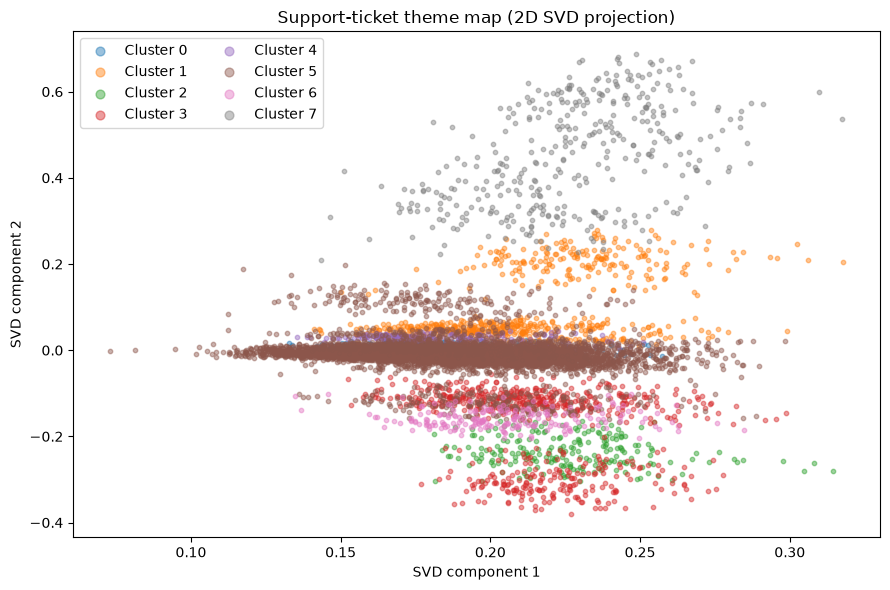

In [14]:
terms=np.array(cluster_vectorizer.get_feature_names_out())
centers_tfidf = []
for cluster_id in range(best_k):
    members = np.where(clusters==cluster_id)[0]
    mean_vec = np.asarray(X_cluster[members].mean(axis=0)).ravel()
    top_terms = terms[np.argsort(-mean_vec)[:10]].tolist()
    centers_tfidf.append({
        "cluster":cluster_id,
        "tickets":len(members),
        "top_terms":", ".join(top_terms),
        "dominant_ticket_type":work.iloc[members]["Ticket Type"].mode().iloc[0]
    })

cluster_report=pd.DataFrame(centers_tfidf).set_index("cluster")
display(cluster_report)

# Two-dimensional visualisation only; clustering itself used 40 SVD dimensions.
svd2=TruncatedSVD(n_components=2,random_state=RANDOM_STATE)
Z2=svd2.fit_transform(X_cluster)

fig, ax = plt.subplots(figsize=(9,6))
for cluster_id in sorted(np.unique(clusters)):
    mask=clusters==cluster_id
    ax.scatter(Z2[mask,0],Z2[mask,1],s=10,alpha=0.45,label=f"Cluster {cluster_id}")
ax.set_title("Support-ticket theme map (2D SVD projection)")
ax.set_xlabel("SVD component 1")
ax.set_ylabel("SVD component 2")
ax.legend(markerscale=2,ncol=2)
plt.tight_layout()
plt.show()

## 10. Age and gender subgroup audit

Age and gender remain available for analysis, but are not predictive inputs. We audit routing accuracy to see whether model quality differs across demographic groups.

Age-band audit:


,tickets,routing_accuracy,urgent_prevalence,urgent_alert_rate
group,,,,
18-24,235,19.15%,56.17%,100.00%
25-34,285,18.60%,44.56%,100.00%
35-44,304,19.08%,53.95%,100.00%
45-54,342,18.71%,47.08%,100.00%
55-64,334,15.87%,52.10%,100.00%
65+,194,15.98%,52.58%,100.00%


Gender audit:


,tickets,routing_accuracy,urgent_prevalence,urgent_alert_rate
group,,,,
Female,554,19.49%,47.11%,100.00%
Male,610,16.07%,50.98%,100.00%
Other,530,18.49%,54.34%,100.00%


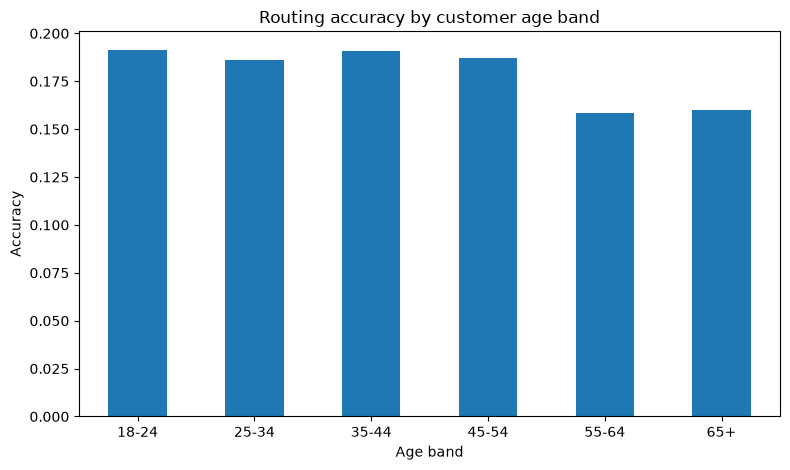

In [15]:
audit = test_df[["Customer Age","Customer Gender","Ticket Type"]].copy()
audit["route_correct"] = (
    test_route_pred == y_test_type.to_numpy()
).astype(int)
audit["urgent_actual"] = y_test_urgent.to_numpy()
audit["urgent_pred"] = test_urgent_pred

audit["age_band"] = pd.cut(
    audit["Customer Age"],
    bins=[0,24,34,44,54,64,200],
    labels=["18-24","25-34","35-44","45-54","55-64","65+"],
    include_lowest=True
)

def audit_table(group_col):
    rows=[]
    for group,g in audit.groupby(group_col,observed=True):
        rows.append({
            "group":str(group),
            "tickets":len(g),
            "routing_accuracy":g["route_correct"].mean(),
            "urgent_prevalence":g["urgent_actual"].mean(),
            "urgent_alert_rate":g["urgent_pred"].mean()
        })
    return pd.DataFrame(rows).set_index("group")

age_audit=audit_table("age_band")
gender_audit=audit_table("Customer Gender")

print("Age-band audit:")
display(age_audit.style.format({
    "routing_accuracy":"{:.2%}",
    "urgent_prevalence":"{:.2%}",
    "urgent_alert_rate":"{:.2%}"
}))
print("Gender audit:")
display(gender_audit.style.format({
    "routing_accuracy":"{:.2%}",
    "urgent_prevalence":"{:.2%}",
    "urgent_alert_rate":"{:.2%}"
}))

fig, ax = plt.subplots(figsize=(8,4.8))
age_audit["routing_accuracy"].plot(kind="bar",ax=ax)
ax.set_title("Routing accuracy by customer age band")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Age band")
ax.tick_params(axis="x",rotation=0)
plt.tight_layout()
plt.show()

## 11. PII-safe operational triage queue

The final score combines:
- model confidence that the ticket is urgent;
- routing uncertainty (low maximum category probability);
- a small channel handling weight.

This is a **triage score**, not a true contractual SLA-breach probability.

In [16]:
route_prob = router.predict_proba(X_test)
route_conf = route_prob.max(axis=1)
route_pred = router.classes_[route_prob.argmax(axis=1)]

channel_weight = {
    "Phone":1.00,
    "Chat":0.90,
    "Social media":0.80,
    "Email":0.70
}
channel_signal = test_df["Ticket Channel"].map(channel_weight).fillna(0.75).to_numpy()

triage_score = (
    0.60 * test_urgent_prob
    + 0.25 * (1-route_conf)
    + 0.15 * channel_signal
)

queue = test_df[[
    "Ticket ID","Customer Age","Customer Gender",
    "Product Purchased","Ticket Channel","Ticket Subject",
    "Ticket Description Clean","Ticket Type","Ticket Priority"
]].copy()

queue["predicted_route"] = route_pred
queue["route_confidence"] = route_conf
queue["urgent_probability"] = test_urgent_prob
queue["triage_score"] = triage_score
queue["predicted_urgent"] = test_urgent_pred
queue["ticket_key"] = queue["Ticket ID"].apply(
    lambda x: "TKT-" + hashlib.sha256(str(x).encode()).hexdigest()[:8].upper()
)

queue = queue.drop(columns=["Ticket ID"])
queue = queue.sort_values(
    ["predicted_urgent","triage_score"],
    ascending=[False,False]
).reset_index(drop=True)

print("Top 30 triage tickets:")
display(queue[[
    "ticket_key","Ticket Subject","Product Purchased","Ticket Channel",
    "predicted_route","route_confidence","urgent_probability",
    "triage_score","Customer Age","Customer Gender"
]].head(30).style.format({
    "route_confidence":"{:.2%}",
    "urgent_probability":"{:.2%}",
    "triage_score":"{:.3f}",
    "Customer Age":"{:.0f}"
}))

queue.to_csv("support_ticket_triage_queue.csv",index=False)
cluster_report.to_csv("support_ticket_theme_clusters.csv")
age_audit.to_csv("support_ticket_age_audit.csv")
gender_audit.to_csv("support_ticket_gender_audit.csv")
print("Operational artefacts exported without names or emails.")

Top 30 triage tickets:


,ticket_key,Ticket Subject,Product Purchased,Ticket Channel,predicted_route,route_confidence,urgent_probability,triage_score,Customer Age,Customer Gender
0,TKT-ECD8409A,Peripheral compatibility,Asus ROG,Phone,Product inquiry,25.74%,75.63%,0.789,48,Male
1,TKT-16956445,Hardware issue,Dyson Vacuum Cleaner,Chat,Product inquiry,39.90%,83.08%,0.784,38,Male
2,TKT-5ECEBDEC,Account access,Apple AirPods,Social media,Technical issue,41.08%,85.90%,0.783,33,Male
3,TKT-4523540F,Account access,Xbox,Chat,Product inquiry,30.83%,78.59%,0.779,63,Other
4,TKT-7B8B6E39,Product recommendation,Philips Hue Lights,Social media,Refund request,29.11%,80.07%,0.778,24,Male
5,TKT-D4E5F572,Product setup,Fitbit Versa Smartwatch,Email,Technical issue,27.08%,81.71%,0.778,65,Female
6,TKT-F76CB816,Product recommendation,Dell XPS,Phone,Refund request,35.92%,77.78%,0.777,56,Other
7,TKT-3C8B996E,Payment issue,Dell XPS,Chat,Refund request,39.72%,81.78%,0.776,54,Female
8,TKT-CBFBF617,Refund request,Amazon Kindle,Phone,Refund request,39.38%,78.60%,0.773,59,Other
9,TKT-E254AD19,Payment issue,Nest Thermostat,Phone,Product inquiry,36.33%,76.78%,0.770,70,Female


Operational artefacts exported without names or emails.


## 12. Executive summary

In [17]:
print(f"""
AI SUPPORT-TICKET INTELLIGENCE SUMMARY
--------------------------------------
Dataset: public Kaggle customer-support benchmark
Tickets: {len(work):,}
Ticket types: {work['Ticket Type'].nunique()}
Priority labels: {work['Ticket Priority'].nunique()}

Names/emails used as model features: NO
Age retained in dataset: YES
Gender retained in dataset: YES
Age/gender used for routing or urgency prediction: NO
Age/gender subgroup audits: YES

Routing accuracy: {route_test['accuracy']:.2%}
Routing macro F1: {route_test['macro_F1']:.4f}

Urgency ROC-AUC: {urgency_test['ROC_AUC']:.4f}
Urgency PR-AUC: {urgency_test['PR_AUC']:.4f}
Urgency precision: {urgency_test['precision']:.2%}
Urgency recall: {urgency_test['recall']:.2%}
Urgency F1: {urgency_test['F1']:.4f}

Discovered ticket-theme clusters: {best_k}
Age-band routing accuracy range: {age_audit['routing_accuracy'].min():.2%} -> {age_audit['routing_accuracy'].max():.2%}
Gender routing accuracy range: {gender_audit['routing_accuracy'].min():.2%} -> {gender_audit['routing_accuracy'].max():.2%}

The project converts incoming ticket text into routing predictions,
urgency estimates, similar-case retrieval, recurring-theme clusters
and a PII-safe prioritised support queue.
""")


AI SUPPORT-TICKET INTELLIGENCE SUMMARY
--------------------------------------
Dataset: public Kaggle customer-support benchmark
Tickets: 8,469
Ticket types: 5
Priority labels: 4

Names/emails used as model features: NO
Age retained in dataset: YES
Gender retained in dataset: YES
Age/gender used for routing or urgency prediction: NO
Age/gender subgroup audits: YES

Routing accuracy: 17.95%
Routing macro F1: 0.1796

Urgency ROC-AUC: 0.5062
Urgency PR-AUC: 0.5096
Urgency precision: 50.77%
Urgency recall: 100.00%
Urgency F1: 0.6735

Discovered ticket-theme clusters: 8
Age-band routing accuracy range: 15.87% -> 19.15%
Gender routing accuracy range: 16.07% -> 19.49%

The project converts incoming ticket text into routing predictions,
urgency estimates, similar-case retrieval, recurring-theme clusters
and a PII-safe prioritised support queue.



### Production roadmap
- replace the benchmark dataset with authenticated production ticket history;
- true ticket-created timestamps and contractual SLA clocks;
- multilingual transformer embeddings;
- calibrated probability estimates;
- agent-team capacity and skill-based routing;
- retrieval from approved knowledge-base articles;
- human feedback loops from corrected routes;
- drift monitoring as product/issues change;
- fairness monitoring across customer segments without using demographics as routing inputs;
- online measurement: first-contact resolution, response time, reopen rate and CSAT.

### Interview defence
**“I built this as an operations system rather than a single classifier. Ticket text drives routing and urgency; names/emails are excluded; age and gender are retained only for subgroup auditing. I added semantic case retrieval, unsupervised issue discovery and a PII-safe triage queue, and I explicitly avoid calling the urgency score an SLA-breach probability because the benchmark lacks a reliable ticket-created timestamp.”**